# 涨跌停情绪因子：分组回测（连续因子有效性检验）

用 `backtest_timeseries_factor` 替代原阈值二值信号择时逻辑，
直接对连续因子做分位数分组回测，检验因子值高低分组间的区分力。

**研究流程：** 构造共用因子 → 批量分组回测（跨因子×跨指数×跨持仓期）→ 汇总对比


In [46]:
import importlib
import sys
import warnings
from collections import defaultdict
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# 项目根目录自动探测
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from my_utils.fun import read_day_data
from my_utils.rqdata import RqData
from 因子回测.alpha import backtest_timeseries_factor
from 因子回测.涨跌停情绪因子.timing_engine import (
    build_daily_sentiment_factors, prepare_stock_daily,
)

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 27)
DATA_SOURCE = "rq_stock_all_data"
WINDOW = 5
HORIZONS = (1, 3, 5, 10)
GROUP_WINDOW = 252

FACTOR_COLUMNS = [
    "limit_up_ratio",
    "limit_down_ratio",
    "limit_up_next_ret",
    "limit_down_next_ret",
]
FACTOR_LABELS = {
    "limit_up_ratio": "涨停占比",
    "limit_down_ratio": "跌停占比",
    "limit_up_next_ret": "涨停次日收益",
    "limit_down_next_ret": "跌停次日收益",
}

# ── RQData 指数代码 → 中文名称；字典顺序即回测与绘图顺序 ──
BENCHMARKS = {
    "000300.XSHG": "沪深300",
    "000905.XSHG": "中证500",
    "000852.XSHG": "中证1000",
    "399303.XSHE": "国证2000",  # RQData 无中证2000(932000)，用国证2000代替
    # "399006.XSHE": "创业板指",
    # "000688.XSHG": "科创50",
}

In [ ]:
# ===== 1. 构建情绪因子（以 trading_date 为索引） =====
daily_fields = [
    "code", "trading_date", "close", "pre_close", "limit_up", "limit_down",
    "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE, END_DATE, fields=daily_fields, file_path=DATA_SOURCE,
).sort(["code", "trading_date"])

prepared_daily, trading_calendar = prepare_stock_daily(daily_raw)
factor_data = (
    build_daily_sentiment_factors(prepared_daily, trading_calendar, window=WINDOW)
    .to_pandas()
    .assign(trading_date=lambda d: pd.to_datetime(d["trading_date"]))
    .sort_values("trading_date")
    .dropna(subset=FACTOR_COLUMNS, how="all")
    .reset_index(drop=True)
    .set_index("trading_date")
)


# ===== 2. 获取多指数收益（宽表），与因子数据合并 =====
rq_returns = RqData().get_return(
    list(BENCHMARKS), START_DATE, END_DATE,
)
benchmark_rets = (
    rq_returns.reset_index()[["order_book_id", "date", "return"]]
    .assign(
        date=lambda d: pd.to_datetime(d["date"]),
        **{"return": lambda d: pd.to_numeric(d["return"], errors="raise").astype(float)},
    )
    .pipe(lambda df: df.loc[np.isfinite(df["return"]).to_numpy(), :])
    .pivot_table(index="date", columns="order_book_id", values="return")
    .rename(columns=BENCHMARKS)
    .reindex(columns=list(BENCHMARKS.values()))
    .rename_axis("trading_date")
)

# 因子 + 多指数收益 → 一张宽表（trading_date 为索引）
analysis_data = factor_data.join(benchmark_rets, how="inner")
print(f"分析数据范围: {analysis_data.index.min().date()} ~ {analysis_data.index.max().date()}")
print(f"交易日数: {len(analysis_data)}")
display(analysis_data.head())

因子数据范围: 2018-01-08 ~ 2026-07-27
有效交易日: 2073


,limit_up_ratio,limit_down_ratio,limit_up_next_ret,limit_down_next_ret
trading_date,,,,
2026-07-21,0.06141702,0.10415864,0.01059290,-0.02872636
2026-07-22,0.05660377,0.09915287,0.01183158,-0.02766342
2026-07-23,0.07351809,0.09257121,0.01422118,-0.02516323
2026-07-24,0.07486528,0.05638953,0.01126493,-0.02068058
2026-07-27,0.08583526,0.01193226,0.01405765,0.02411682


  回测进度: 10/64 (limit_up_ratio, zz1000, 3d)
  回测进度: 20/64 (limit_down_ratio, hs300, 10d)
  回测进度: 30/64 (limit_down_ratio, zz2000, 3d)
  回测进度: 40/64 (limit_up_next_ret, zz500, 10d)
  回测进度: 50/64 (limit_down_next_ret, hs300, 3d)
  回测进度: 60/64 (limit_down_next_ret, zz1000, 10d)

批量回测完成！共 64 条有效记录，64 组 NAV 已缓存


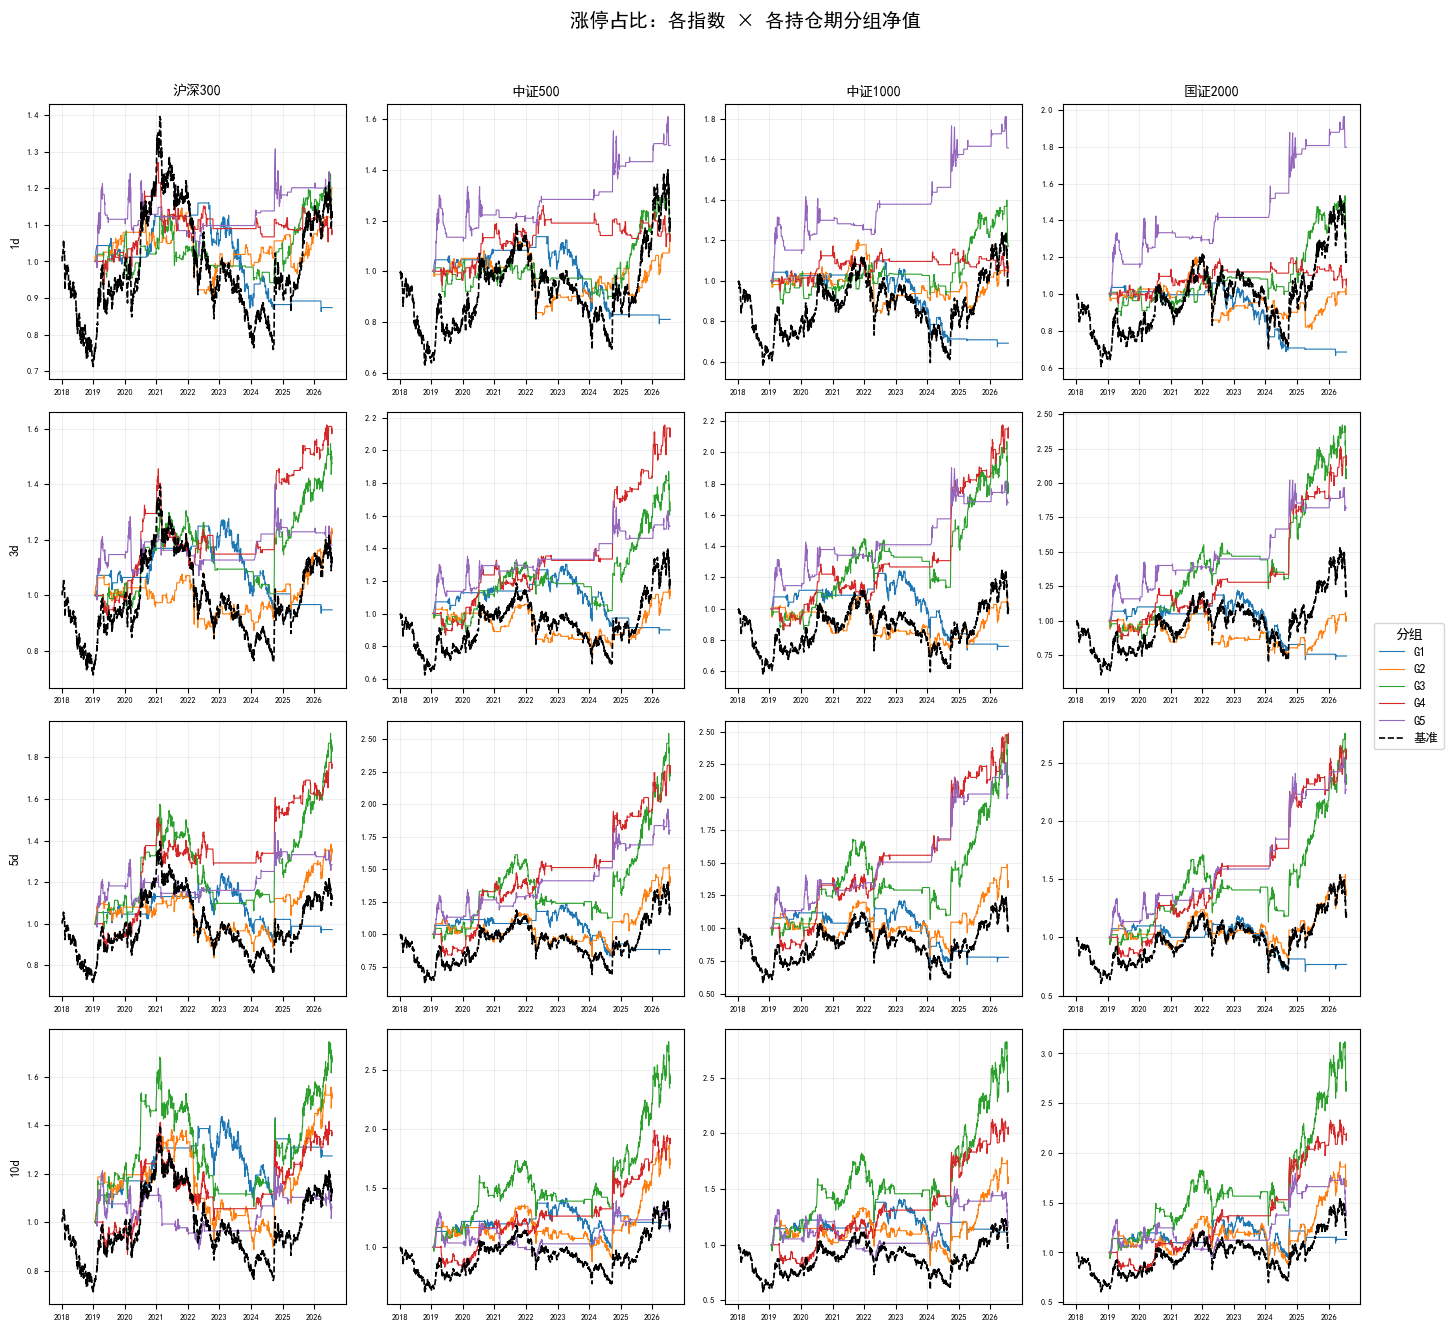

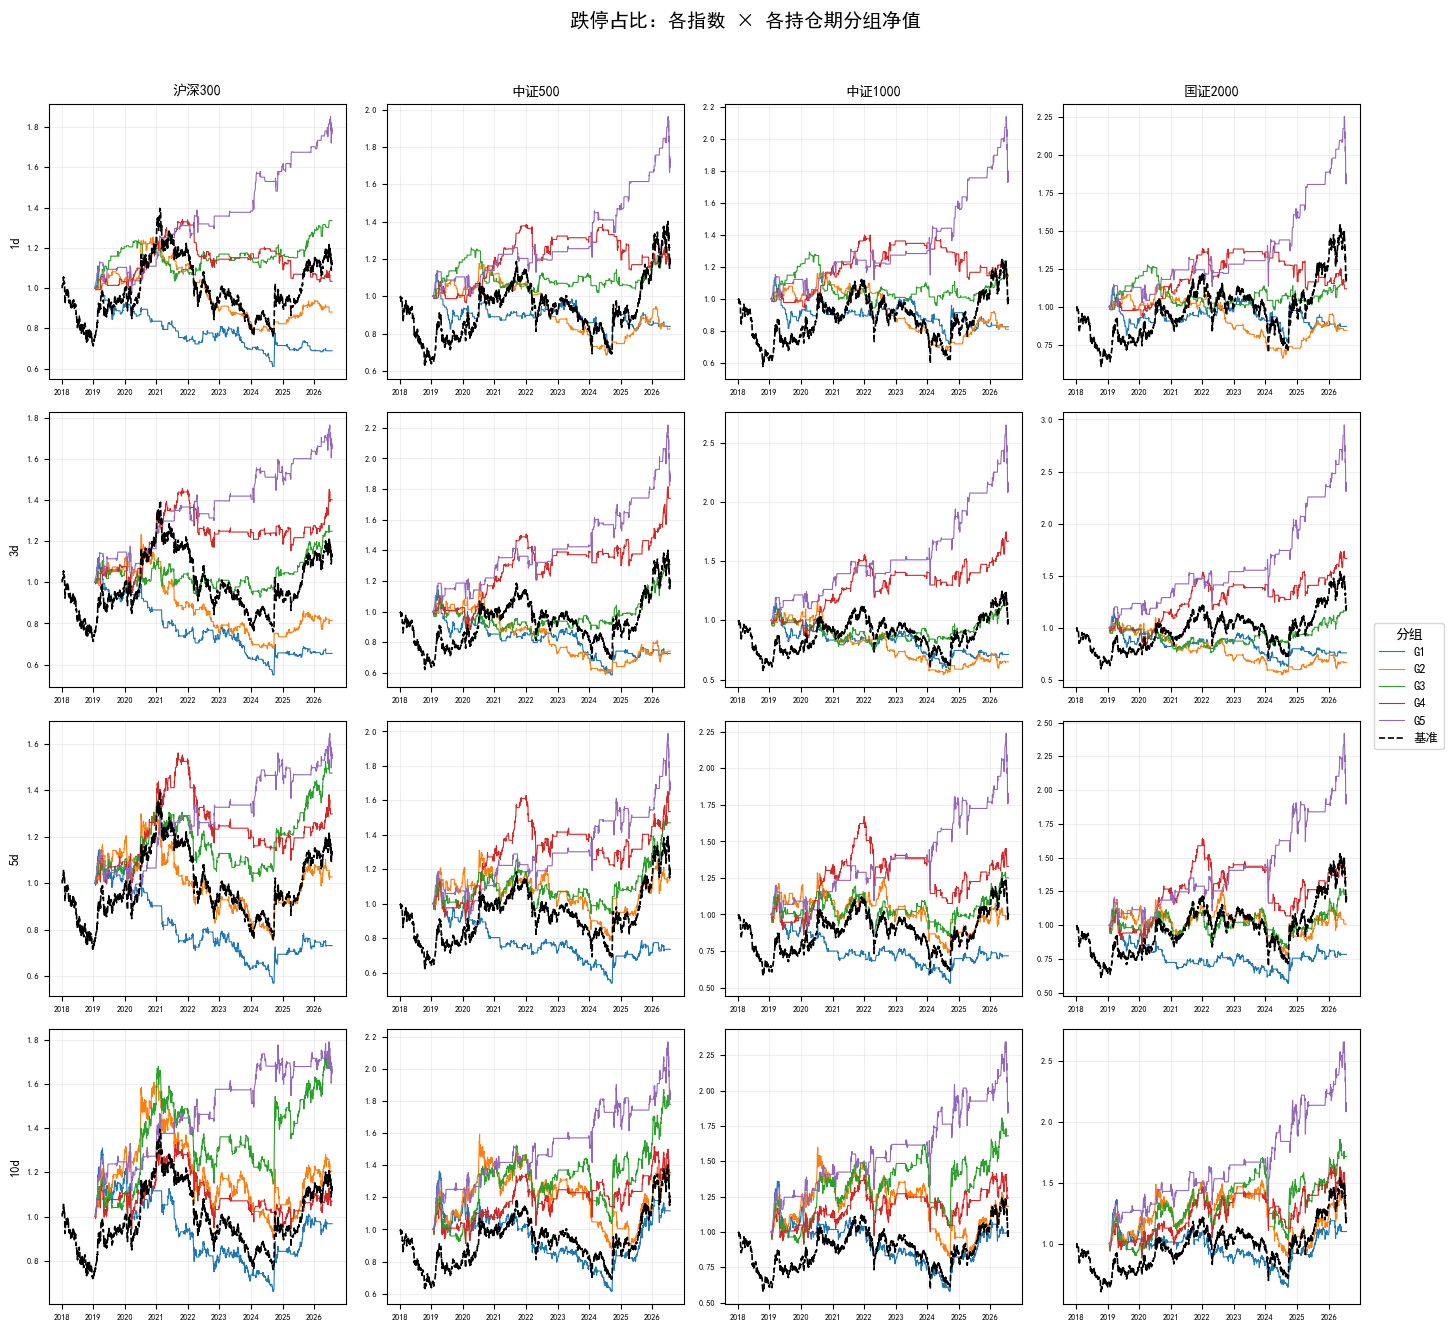

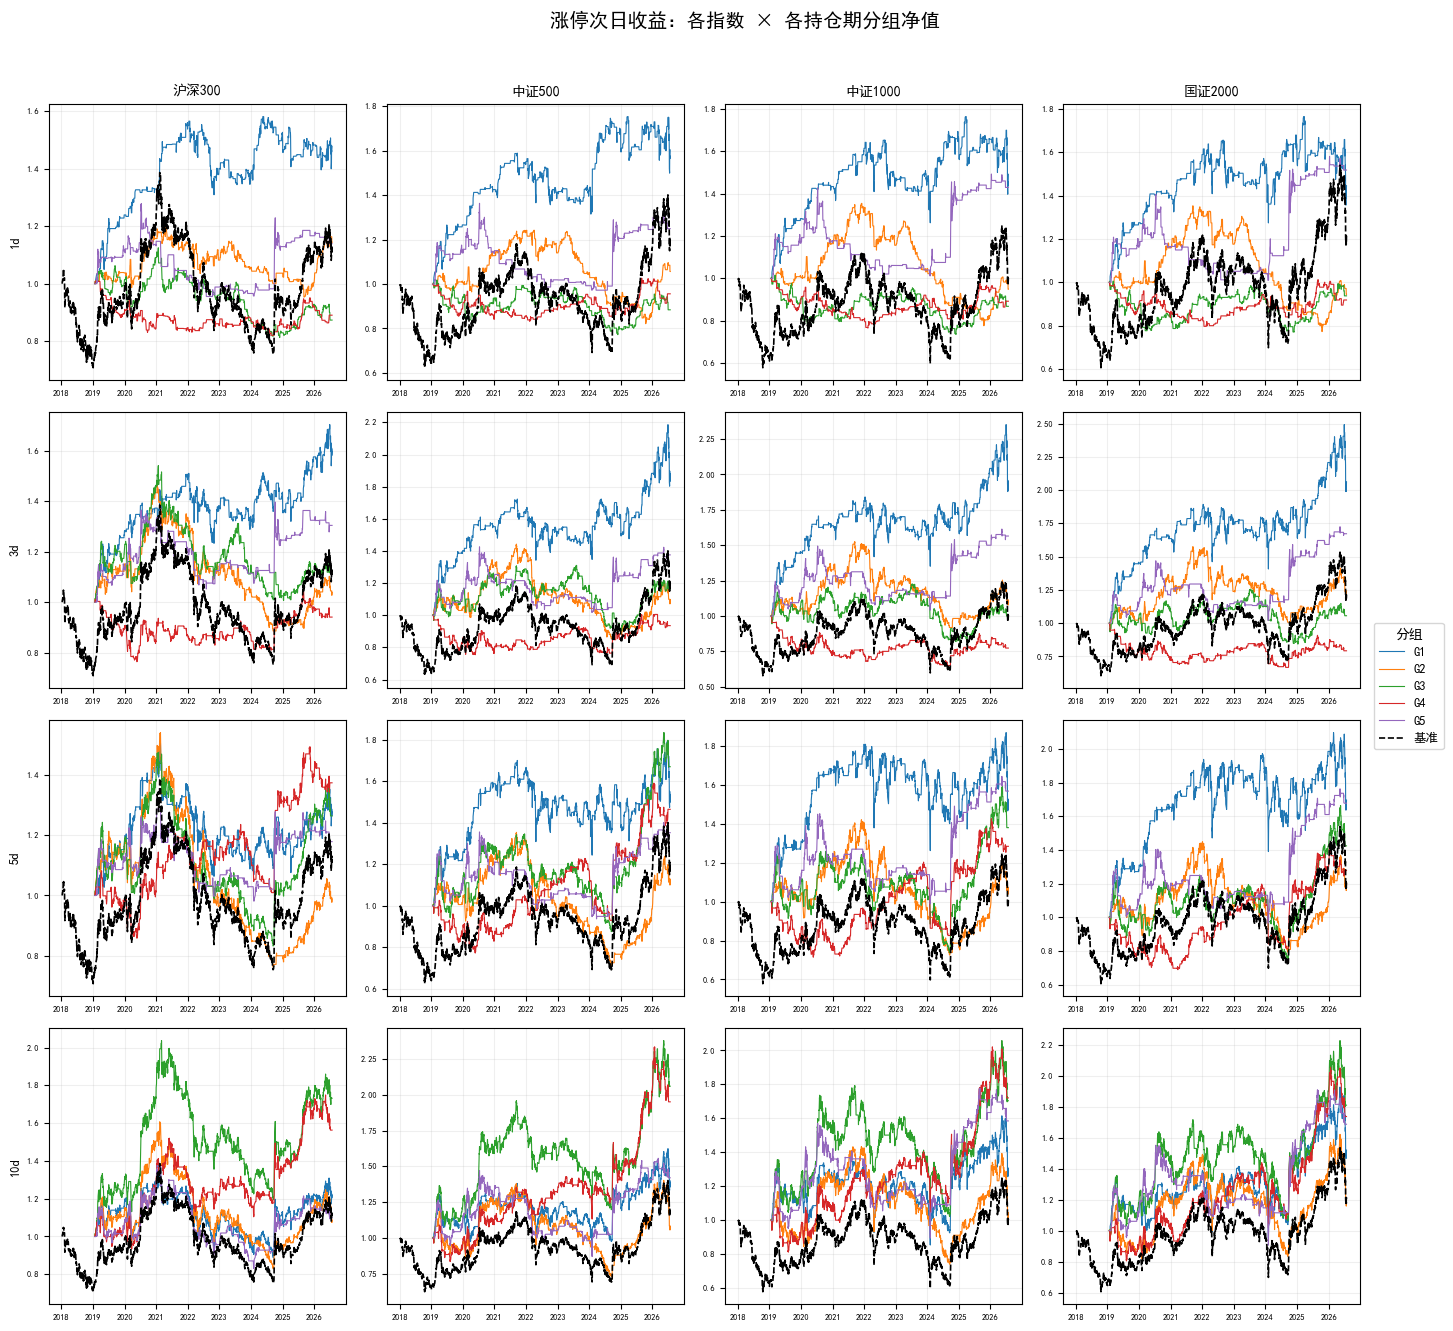

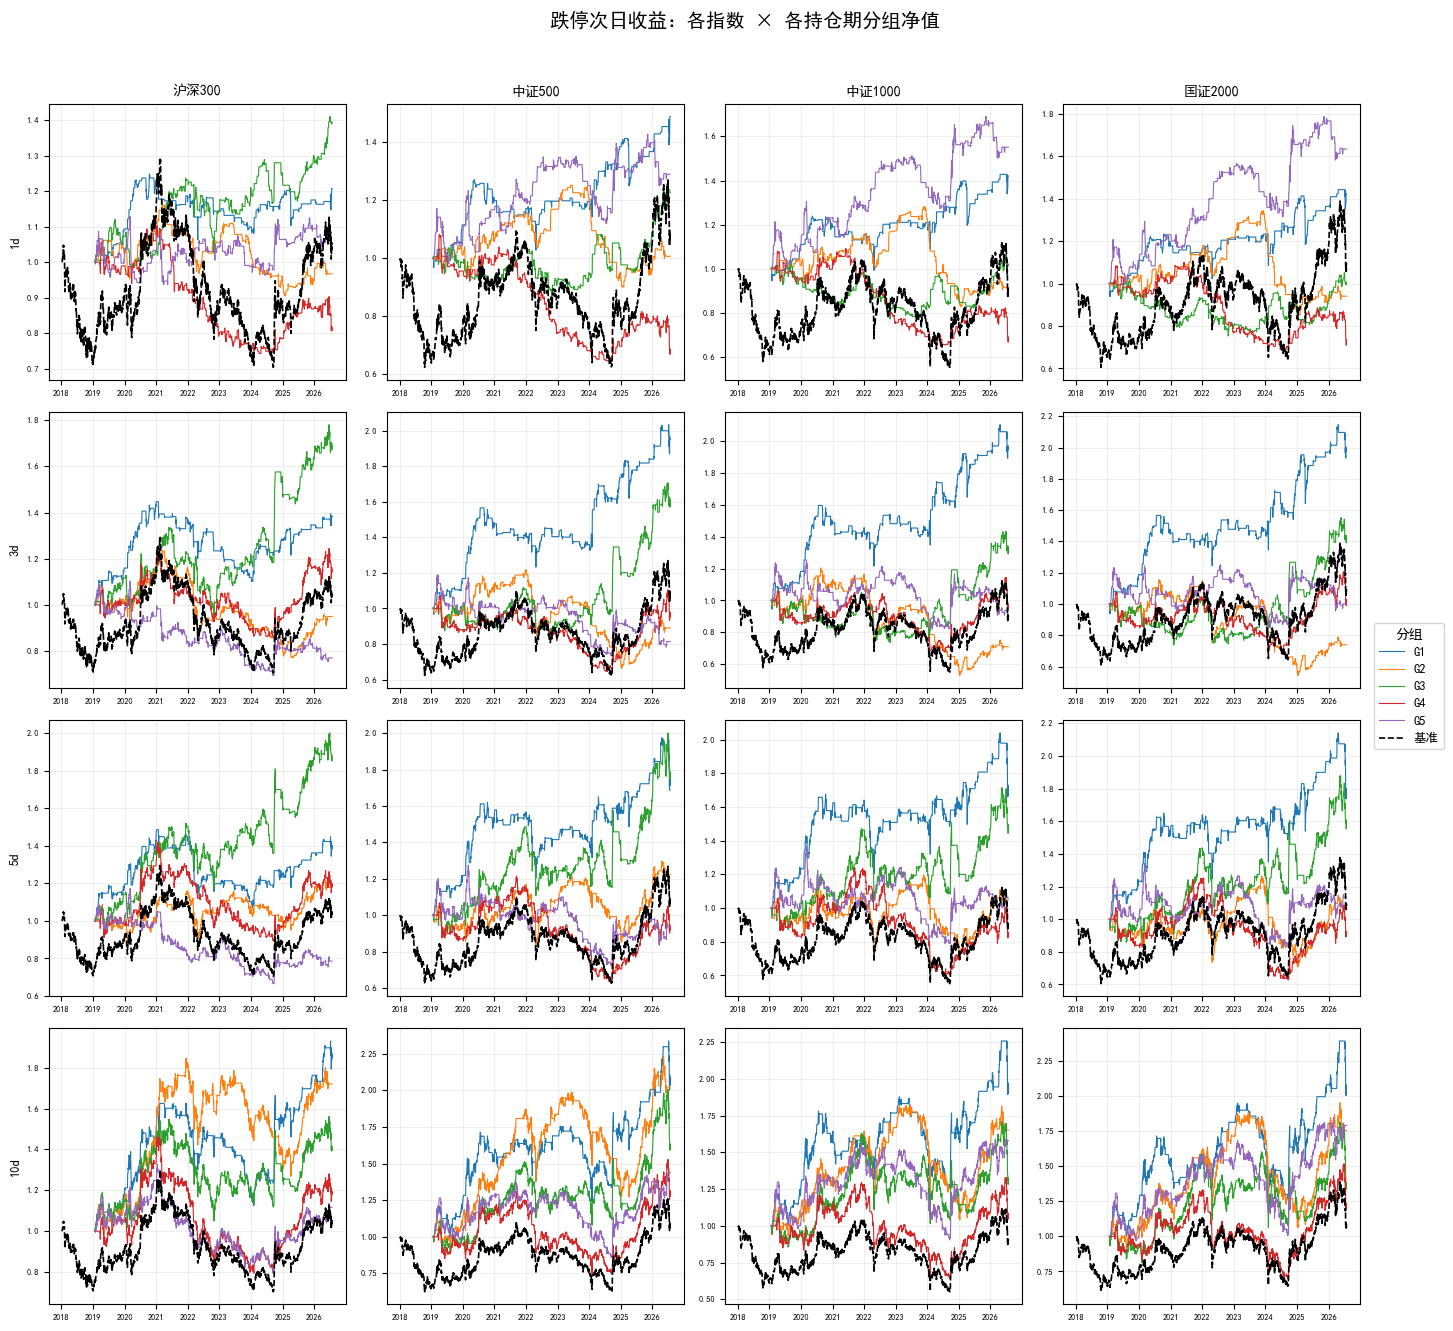

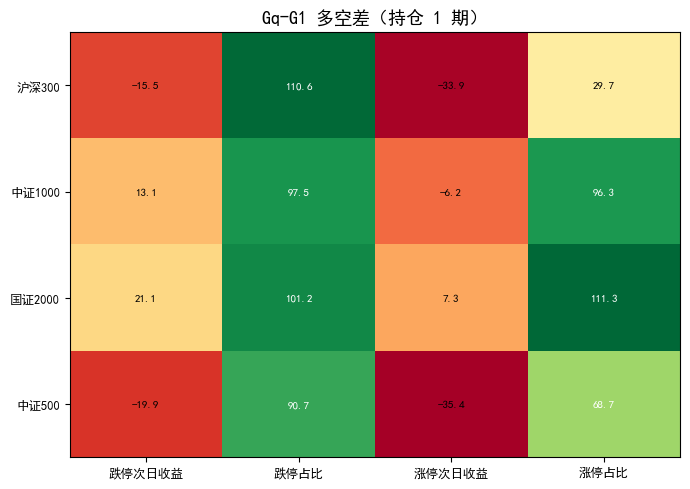

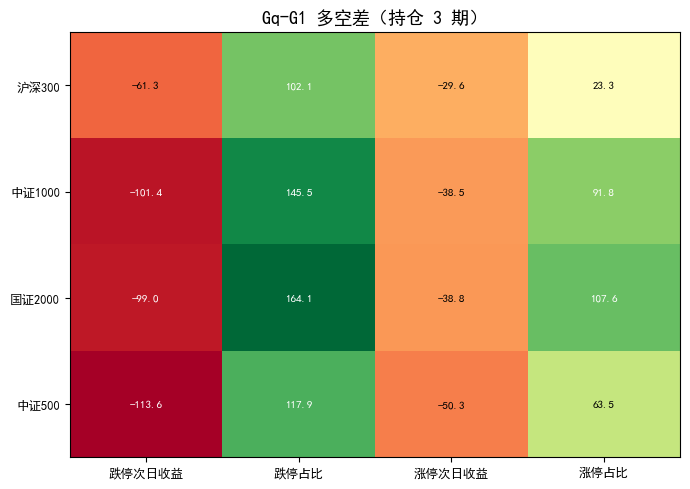

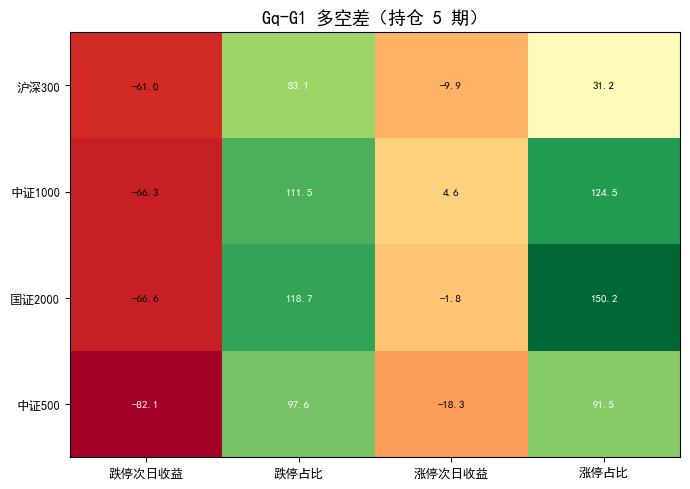

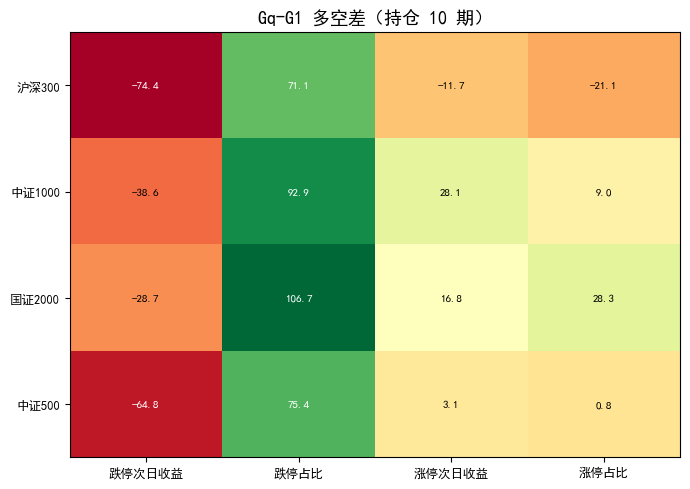

In [49]:
# ===== 3. 批量回测与结果提取 =====

def extract_metrics(result, factor, benchmark, horizon):
    """从 backtest_timeseries_factor 结果中提取关键指标。"""
    perf = result["group_performance"]
    groups = [g for g in perf.index if g.startswith("G")]
    if len(groups) < 2:
        return None

    g1 = perf.loc["G1"]
    gq = perf.loc[groups[-1]]
    bm = perf.loc["买入持有基准"]

    cum_vals = [perf.loc[g, "累计收益"] for g in groups]
    monotonic_up = all(
        cum_vals[i] <= cum_vals[i + 1] for i in range(len(cum_vals) - 1)
    )

    return {
        "factor": factor,
        "benchmark": benchmark,
        "horizon": horizon,
        "G1_收益": g1["累计收益"],
        "Gq_收益": gq["累计收益"],
        "Gq-G1": gq["累计收益"] - g1["累计收益"],
        "G1_夏普": g1["夏普比率"],
        "Gq_夏普": gq["夏普比率"],
        "基准_收益": bm["累计收益"],
        "单调递增": monotonic_up,
    }


# 批量回测（analysis_data 来自上一步：含因子列 + 多指数收益列的宽表）
rows = []
nav_cache = {}
total = len(FACTOR_COLUMNS) * len(BENCHMARKS) * len(HORIZONS)
count = 0

for factor in FACTOR_COLUMNS:
    for benchmark in BENCHMARKS.values():
        # 从宽表直接取因子列 + 对应指数收益列，无需 merge
        df = analysis_data[[factor, benchmark]].dropna().copy()
        df.columns = [factor, "ret_pct"]
        df["ret_pct"] *= 100

        for horizon in HORIZONS:
            count += 1
            if count % 10 == 0:
                print(f"  回测进度: {count}/{total} ({factor}, {benchmark}, {horizon}d)")

            result = backtest_timeseries_factor(
                df,
                factor_col=factor,
                index_ret_col="ret_pct",
                q=5,
                hold_period=horizon,
                plot=False,
                verbose=False,
                window=GROUP_WINDOW,
            )

            metrics = extract_metrics(result, factor, benchmark, horizon)
            if metrics is not None:
                rows.append(metrics)

            # 分组与基准已经在同一张净值宽表中，共享完全相同的日期索引。
            nav_cache[(factor, benchmark, horizon)] = result["group_nav"]

print(f"\n批量回测完成！共 {len(rows)} 条有效记录，{len(nav_cache)} 组 NAV 已缓存")

summary = pd.DataFrame(rows)


# ========= 批量回测结束后绘制合成图 =========

# ----- 图 A：每个因子一张多面板净值图（行=持仓期，列=指数） -----
for factor in FACTOR_COLUMNS:
    fig, axes = plt.subplots(
        len(HORIZONS), len(BENCHMARKS),
        figsize=(3 * len(BENCHMARKS) + 3, 3 * len(HORIZONS) + 1),
        squeeze=False,
    )
    for hi, horizon in enumerate(HORIZONS):
        for bi, benchmark in enumerate(BENCHMARKS.values()):
            ax = axes[hi][bi]
            key = (factor, benchmark, horizon)
            if key not in nav_cache:
                ax.set_visible(False)
                continue

            nav = nav_cache[key]
            nav = nav / nav.iloc[0]

            for col in nav.columns:
                is_benchmark = col == "买入持有基准"
                ax.plot(
                    nav.index, nav[col], label=col,
                    color="black" if is_benchmark else None,
                    linewidth=1.2 if is_benchmark else 0.8,
                    linestyle="--" if is_benchmark else "-",
                )

            if hi == 0:
                ax.set_title(benchmark, fontsize=10)
            if bi == 0:
                ax.set_ylabel(f"{horizon}d", fontsize=9)
            ax.tick_params(labelsize=6)
            ax.grid(alpha=0.2)

    # 图例放在最右侧（从第一个有效子图取 handles）
    for ax in axes.flat:
        if ax.has_data():
            handles, labels = ax.get_legend_handles_labels()
            break
    else:
        handles, labels = [], []
    if handles:
        fig.legend(handles, labels, loc="center right", fontsize=9, title="分组",
                   bbox_to_anchor=(0.97, 0.5))

    fig.suptitle(f"{FACTOR_LABELS[factor]}：各指数 × 各持仓期分组净值", fontsize=14, y=1.02)
    fig.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# ----- 图 B：Gq-G1 多空差热力图（每个持仓期一张） -----
for horizon in HORIZONS:
    fig, ax = plt.subplots(figsize=(7, 5))
    pivot = summary.query("horizon == @horizon").pivot_table(
        index="benchmark", columns="factor", values="Gq-G1",
    ).reindex(index=BENCHMARKS.values())
    im = ax.imshow(pivot.to_numpy(), cmap="RdYlGn", aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([FACTOR_LABELS[c] for c in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(f"Gq-G1 多空差（持仓 {horizon} 期）", fontsize=13)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val) > pivot.abs().to_numpy().mean() else "black")
    fig.tight_layout()
    plt.show()

In [50]:
# ===== 4. 结果汇总表 =====
# summary 和 nav_cache 已在 Cell 4 中生成

print("Gq-G1 多空差排序（跨指数均值）：")
top_combo = (
    summary.groupby(["factor", "horizon"])["Gq-G1"]
    .mean()
    .sort_values(ascending=False)
)
display(top_combo.to_frame("Gq-G1_均值").style.format("{:.2f}").background_gradient(cmap="RdYlGn"))

# 选单调性好的因子+持仓期
print("\n单调性统计（跨指数）")
mono_view = (
    summary.groupby(["factor", "horizon"])["单调递增"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "单调递增_指数数", "count": "总指数数"})
)
mono_view["单调性比率"] = mono_view["单调递增_指数数"] / mono_view["总指数数"]
display(mono_view.style.format({"单调性比率": "{:.0%}"}).background_gradient(cmap="RdYlGn", subset=["单调递增_指数数"]))

Gq-G1 多空差排序（跨指数均值）：



单调性统计（跨指数）


Gq-G1 最优 TOP 10:


,factor,benchmark,horizon,G1_收益,Gq_收益,Gq-G1,G1_夏普,Gq_夏普,基准_收益,单调递增
29,limit_down_ratio,zz2000,3,-24.80,139.30,164.10,-0.400909,0.680231,77.489613,False
14,limit_up_ratio,zz2000,5,-23.25,126.90,150.15,-0.418205,0.650068,77.489613,False
25,limit_down_ratio,zz1000,3,-29.60,115.86,145.46,-0.474866,0.594832,55.287066,False
10,limit_up_ratio,zz1000,5,-22.36,102.16,124.52,-0.427158,0.542067,55.287066,False
30,limit_down_ratio,zz2000,5,-22.24,96.44,118.68,-0.311515,0.467901,77.489613,True
21,limit_down_ratio,zz500,3,-28.28,89.66,117.93,-0.530023,0.508707,76.525945,True
26,limit_down_ratio,zz1000,5,-29.08,82.42,111.50,-0.399124,0.412612,55.287066,True
12,limit_up_ratio,zz2000,1,-31.56,79.77,111.33,-0.704668,0.472390,77.489613,False
16,limit_down_ratio,hs300,1,-32.03,78.57,110.60,-0.799791,0.594195,47.613452,False
13,limit_up_ratio,zz2000,3,-25.68,81.92,107.60,-0.481853,0.457509,77.489613,False


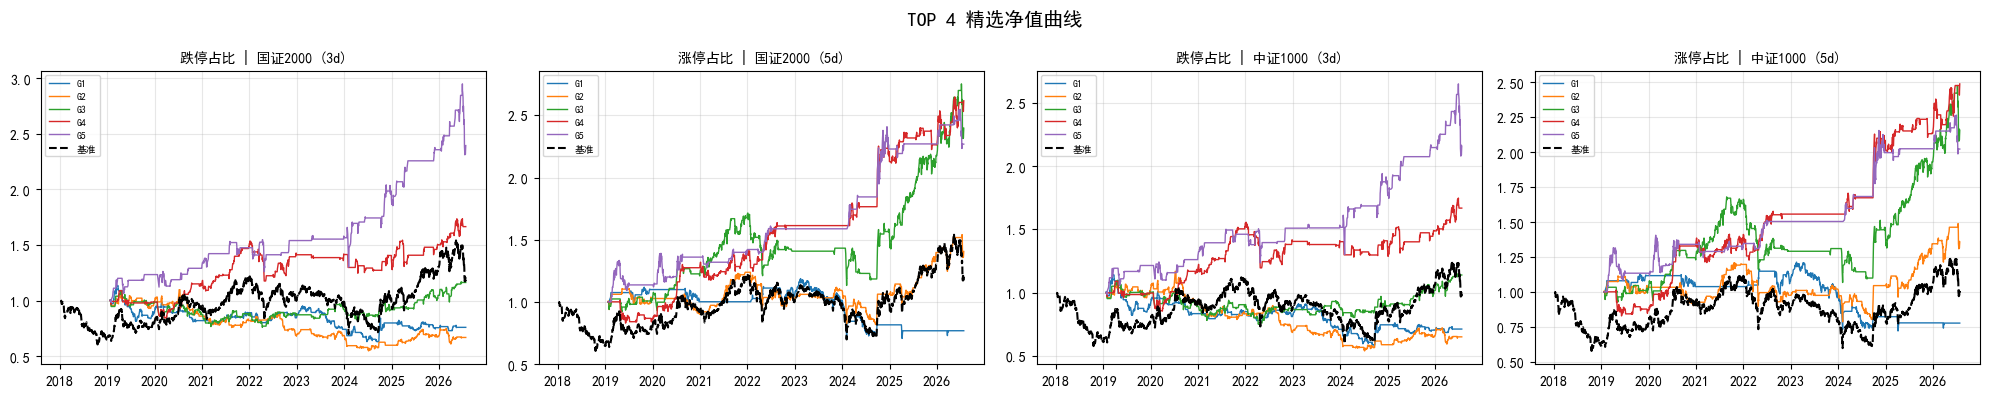

In [51]:
# ===== 5. 选调：最优组合净值对比（使用 nav_cache） =====

ranked = summary.sort_values("Gq-G1", ascending=False)
print("Gq-G1 最优 TOP 10:")
display(ranked.head(10).style.format({
    "Gq-G1": "{:.2f}", "G1_收益": "{:.2f}", "Gq_收益": "{:.2f}",
}))

# TOP 4 放大看（单行多列）
N = 4
ncols = 4
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4), squeeze=False)

for idx, (_, row) in enumerate(ranked.head(N).iterrows()):
    key = (row["factor"], row["benchmark"], int(row["horizon"]))
    if key not in nav_cache:
        continue

    ax = axes[0][idx]
    nav = nav_cache[key]
    nav = nav / nav.iloc[0]

    for col in nav.columns:
        is_benchmark = col == "买入持有基准"
        ax.plot(
            nav.index, nav[col], label=col,
            color="black" if is_benchmark else None,
            linewidth=1.5 if is_benchmark else 1,
            linestyle="--" if is_benchmark else "-",
        )
    ax.set_title(f"{FACTOR_LABELS.get(row.factor, row.factor)} | {row.benchmark} ({int(row.horizon)}d)", fontsize=10)
    ax.legend(fontsize=7, loc="best")
    ax.grid(alpha=0.3)

fig.suptitle("TOP 4 精选净值曲线", fontsize=14)
fig.tight_layout()
plt.show()